<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [3]:
# Transforming Age as Age_num

age_map = {
    'Under 18 years old': 17.0,
    '18-24 years old': 21.0,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70.0
}

df['Age_num'] = df['Age'].map(age_map)

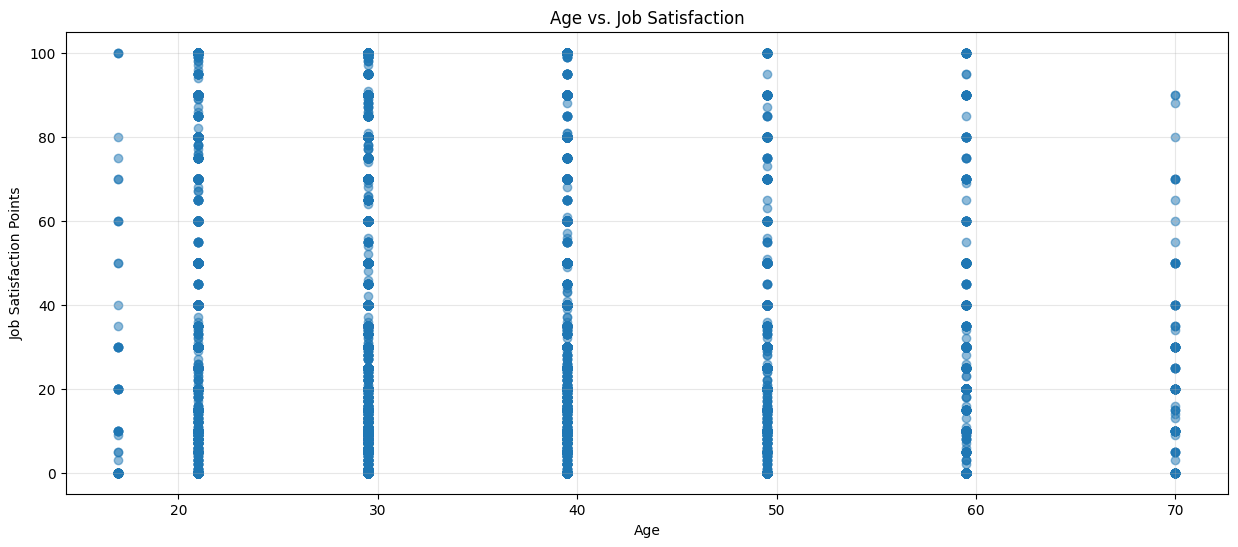

In [4]:
## Scatterplot Age vs. Job Satisfaction

plt.figure(figsize=(15, 6))
plt.scatter(df['Age_num'], df['JobSatPoints_6'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.title('Age vs. Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [5]:
# Deal with outliers in converted comp yearly

comp = df['ConvertedCompYearly']

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['ConvertedCompYearly_clean'] = df['ConvertedCompYearly'].where(
    (df['ConvertedCompYearly'] >= lower) &
    (df['ConvertedCompYearly'] <= upper)
)

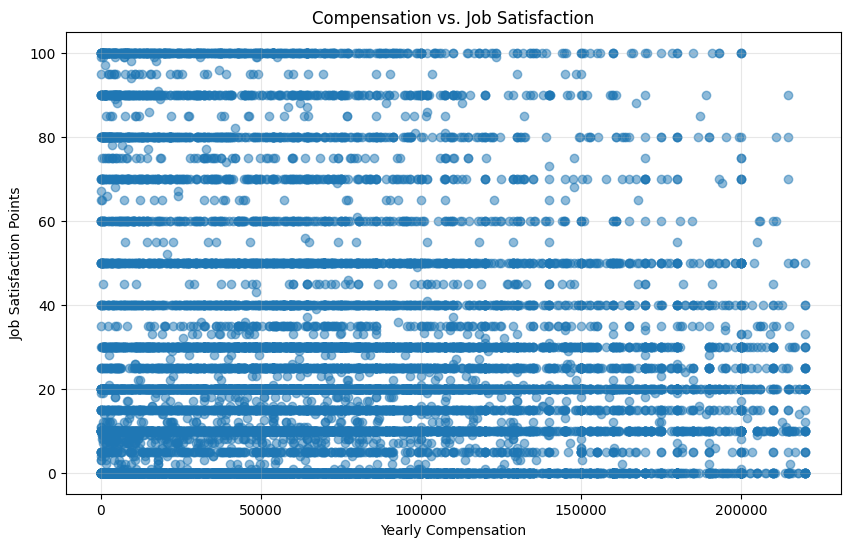

In [6]:
## Scatterplot Compensation vs. Job Satisfaction

plt.figure(figsize=(10, 6))
plt.scatter(df['ConvertedCompYearly_clean'], df['JobSatPoints_6'], alpha=0.5)
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Points')
plt.title('Compensation vs. Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


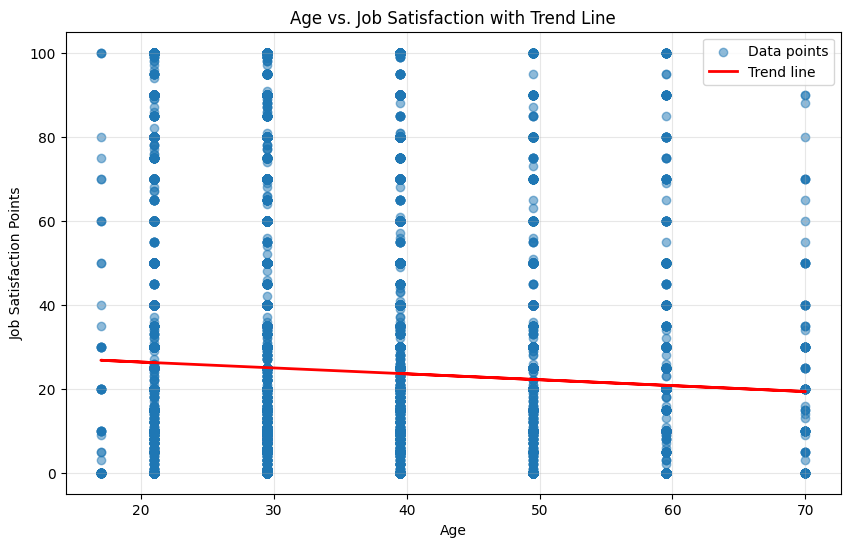

In [7]:
import numpy as np

# Remove NaN values
clean_data = df[['Age_num', 'JobSatPoints_6']].dropna()

# Calculate trend line
z = np.polyfit(clean_data['Age_num'], clean_data['JobSatPoints_6'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(clean_data['Age_num'], clean_data['JobSatPoints_6'], alpha=0.5, label='Data points')
plt.plot(clean_data['Age_num'], p(clean_data['Age_num']), "r-", linewidth=2, label='Trend line')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.title('Age vs. Job Satisfaction with Trend Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [8]:
# Transform data yearscode pro

def convert_experience(x):
    if pd.isna(x):   # handles None and NaN
        return None
    
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        return float(x)

df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_experience)

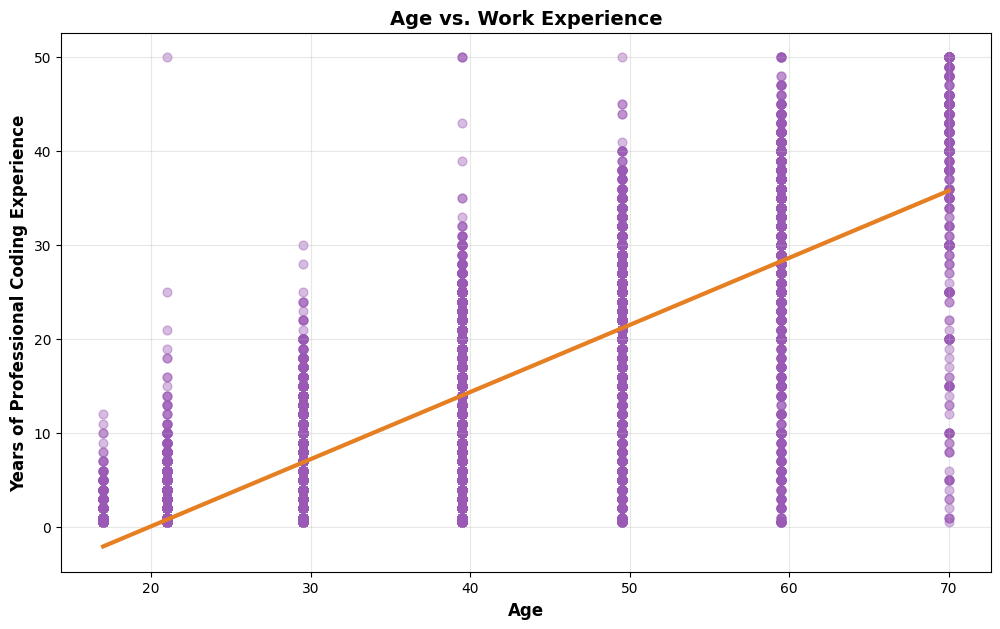

In [9]:
# Scatterplot Age vs. Work Experience
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.regplot(data=df, x='Age_num', y='YearsCodePro_num',
            scatter_kws={'alpha':0.4, 's':40, 'color':'#9b59b6'},
            line_kws={'color':'#e67e22', 'linewidth':3})
plt.xlabel('Age', fontsize=12, fontweight='bold')
plt.ylabel('Years of Professional Coding Experience', fontsize=12, fontweight='bold')
plt.title('Age vs. Work Experience', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
#plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


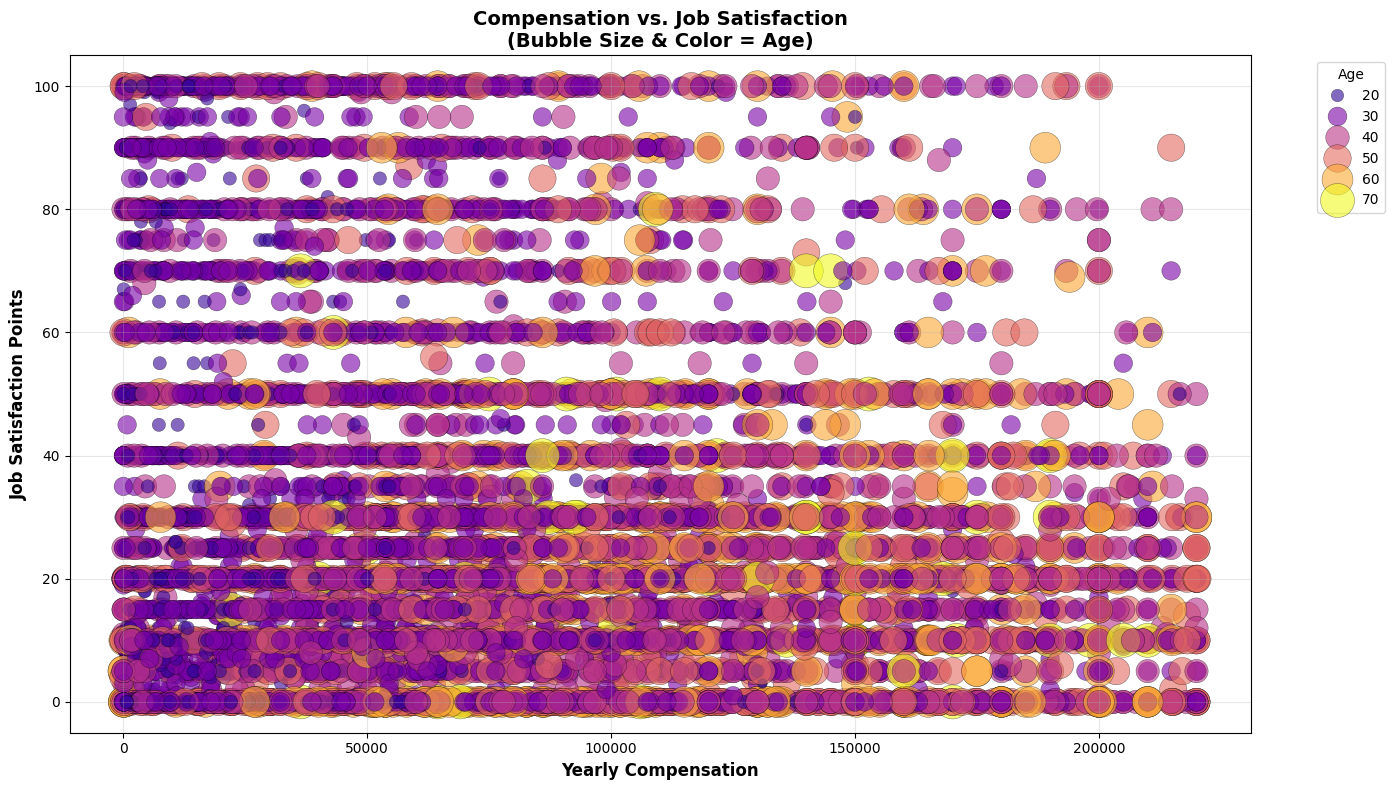

In [10]:
## Write your code here

# Remove NaN values
bubble_data = df[['ConvertedCompYearly_clean', 'JobSatPoints_6', 'Age_num']].dropna()

plt.figure(figsize=(14, 8))
sns.scatterplot(data=bubble_data, 
                x='ConvertedCompYearly_clean', 
                y='JobSatPoints_6',
                size='Age_num',
                hue='Age_num',
                palette='plasma',
                sizes=(50, 600),
                alpha=0.6,
                edgecolor='black',
                linewidth=0.3)
plt.xlabel('Yearly Compensation', fontsize=12, fontweight='bold')
plt.ylabel('Job Satisfaction Points', fontsize=12, fontweight='bold')
plt.title('Compensation vs. Job Satisfaction\n(Bubble Size & Color = Age)', 
          fontsize=14, fontweight='bold')
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


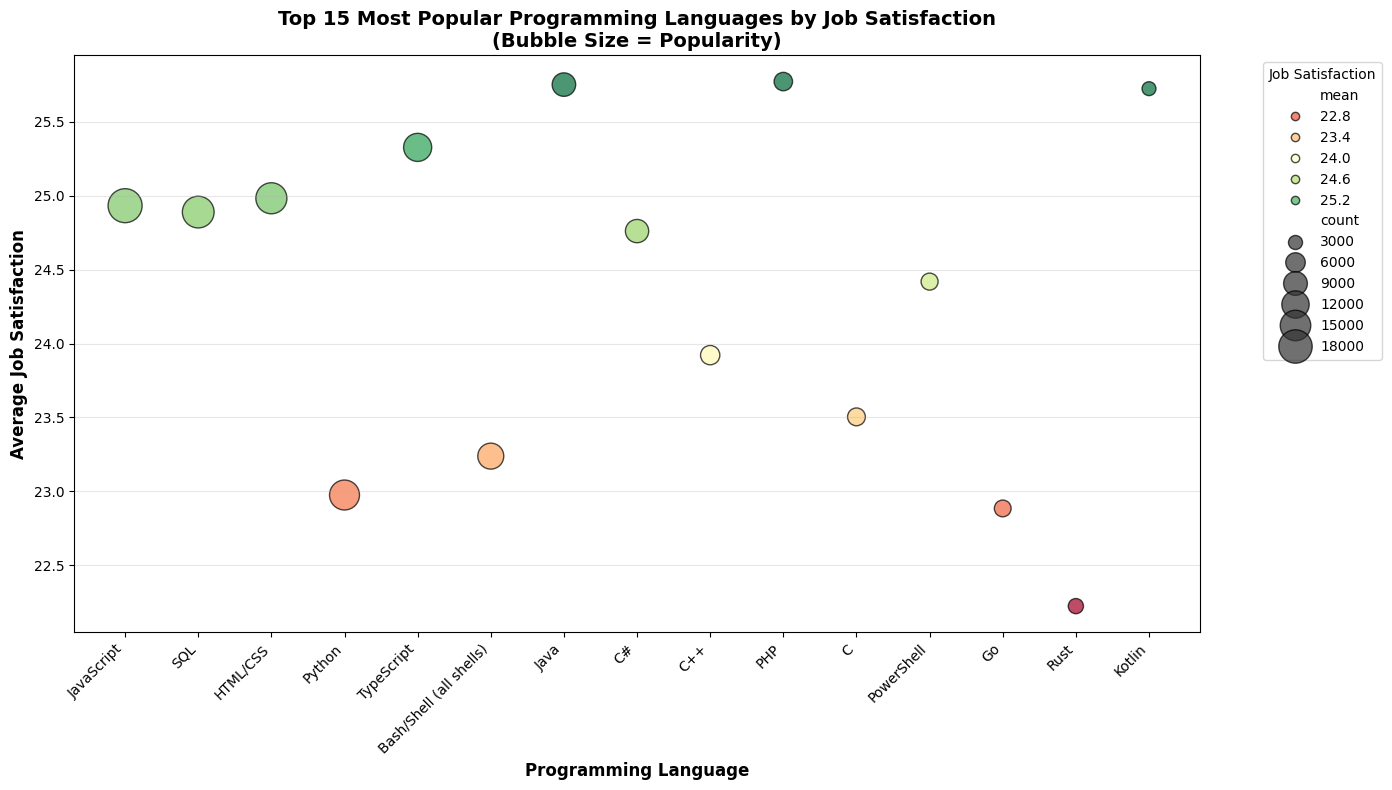

In [11]:
# Expand languages and calculate average satisfaction (BY POPULARITY == NUMBER OF RESPONDENTS)
languages_expanded = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
languages_list = []

for idx, row in languages_expanded.iterrows():
    languages = str(row['LanguageHaveWorkedWith']).split(';')
    for lang in languages:
        languages_list.append({'Language': lang.strip(), 'JobSat': row['JobSatPoints_6']})

lang_df = pd.DataFrame(languages_list)
lang_avg = lang_df.groupby('Language')['JobSat'].agg(['mean', 'count']).reset_index()

# CHANGE: Sort by count (popularity) instead of mean (satisfaction)
lang_avg = lang_avg.sort_values('count', ascending=False).head(15)

plt.figure(figsize=(14, 8))
sns.scatterplot(data=lang_avg, x='Language', y='mean', 
                size='count', hue='mean',
                palette='RdYlGn', sizes=(100, 600),
                alpha=0.7, edgecolor='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Programming Language', fontsize=12, fontweight='bold')
plt.ylabel('Average Job Satisfaction', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Popular Programming Languages by Job Satisfaction\n(Bubble Size = Popularity)', 
          fontsize=14, fontweight='bold')
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

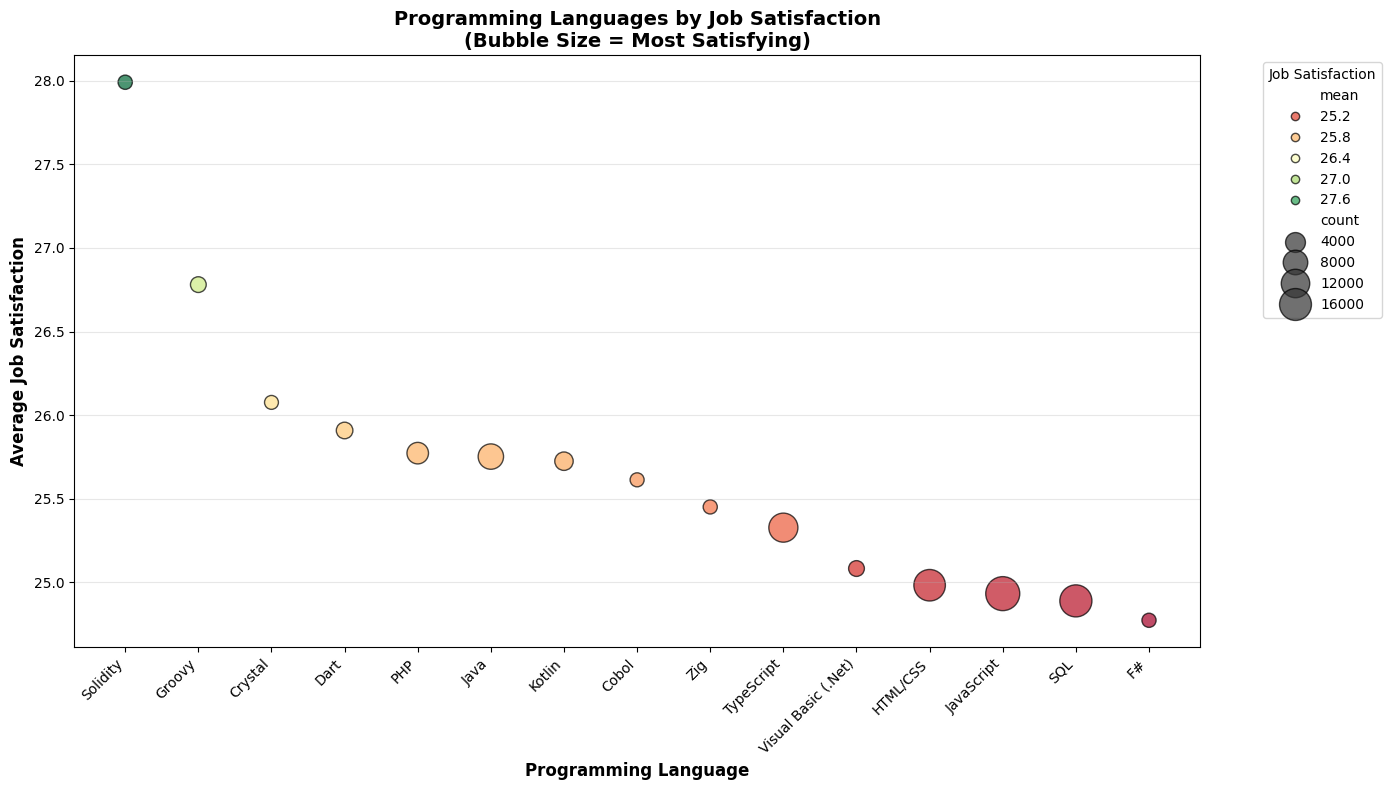

In [12]:
# Expand languages and calculate average satisfaction (BY THE MOST SATISFYING == HIGHER MEAN)

languages_expanded = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
languages_list = []

for idx, row in languages_expanded.iterrows():
    languages = str(row['LanguageHaveWorkedWith']).split(';')
    for lang in languages:
        languages_list.append({'Language': lang.strip(), 'JobSat': row['JobSatPoints_6']})

lang_df = pd.DataFrame(languages_list)
lang_avg = lang_df.groupby('Language')['JobSat'].agg(['mean', 'count']).reset_index()
lang_avg = lang_avg[lang_avg['count'] >= 100].sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(14, 8))
sns.scatterplot(data=lang_avg, x='Language', y='mean', 
                size='count', hue='mean',
                palette='RdYlGn', sizes=(100, 600),
                alpha=0.7, edgecolor='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Programming Language', fontsize=12, fontweight='bold')
plt.ylabel('Average Job Satisfaction', fontsize=12, fontweight='bold')
plt.title('Programming Languages by Job Satisfaction\n(Bubble Size = Most Satisfying)', 
          fontsize=14, fontweight='bold')
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [13]:
# Grouping Employment in broader categories

def simplify_employment(x):
    if pd.isna(x):
        return 'Other'
    
    first = x.split(';')[0]
    
    if first.startswith('Employed'):
        return 'Employed'
    elif first.startswith('Independent'):
        return 'Independent'
    elif first.startswith('Student'):
        return 'Student'
    elif 'but looking for work' in first:
        return 'Unemployed - Looking'
    elif 'and not looking for work' in first:
        return 'Unemployed - Not Looking'
    elif first.startswith('Retired'):
        return 'Retired'
    else:
        return 'Other'

df['Employment_Group'] = df['Employment'].apply(simplify_employment)

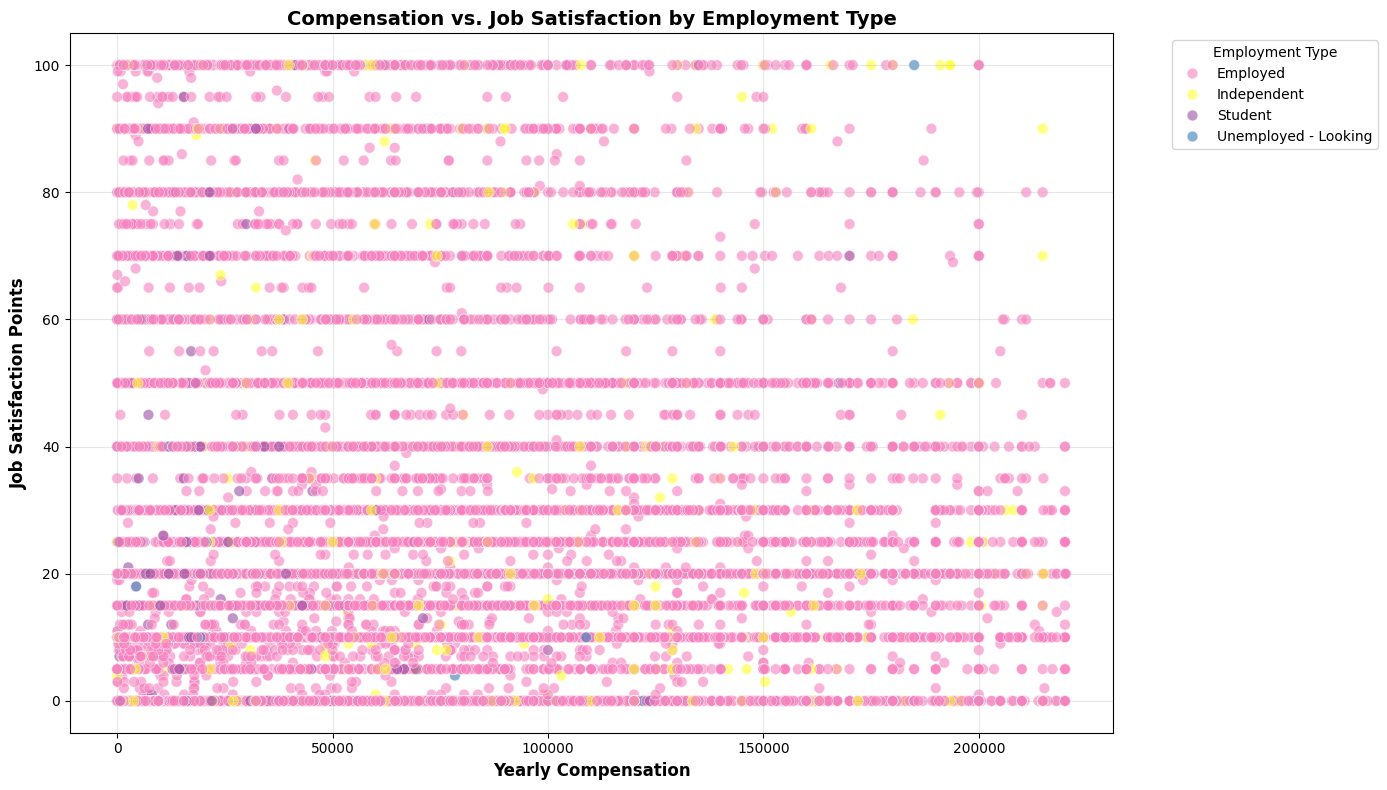

In [14]:
# Scatterplot: Compensation vs. Job Satisfaction by Employment Group

emp_data = df[['ConvertedCompYearly_clean', 'JobSatPoints_6', 'Employment_Group']].dropna()

plt.figure(figsize=(14, 8))
sns.scatterplot(data=emp_data, 
                x='ConvertedCompYearly_clean', 
                y='JobSatPoints_6',
                hue='Employment_Group',
                palette='Set1_r',
                alpha=0.6,
                s=60,
                edgecolor='white',
                linewidth=0.5)
plt.xlabel('Yearly Compensation', fontsize=12, fontweight='bold')
plt.ylabel('Job Satisfaction Points', fontsize=12, fontweight='bold')
plt.title('Compensation vs. Job Satisfaction by Employment Type', 
          fontsize=14, fontweight='bold')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Clean + filter
country_data = df[['YearsCodePro_num', 'Age', 'Country']].dropna()

top_countries = country_data['Country'].value_counts().head(5).index
country_filtered = country_data[country_data['Country'].isin(top_countries)]

# ✔ REMOVE CATEGORY
country_filtered = country_filtered[country_filtered['Age'] != 'Prefer not to say']

# ✔ light label cleaning (safe)
country_filtered['Country_short'] = country_filtered['Country'].apply(
    lambda x: " ".join(str(x).split()[:2])
)

fig = px.scatter(
    country_filtered,
    x='Age',
    y='YearsCodePro_num',
    color='Country_short',
    hover_data=['Age', 'YearsCodePro_num'],
    title='Work Experience vs Age Group by Country',
    template='plotly_white',
    height=500
)

fig.update_traces(marker=dict(size=8, opacity=0.6))
fig.update_xaxes(tickangle=0)
fig.update_yaxes(title='Coding Experience (Years)')

fig.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
